In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import os

# ✅ RUTA DIRECTA A GOOGLE DRIVE
base_dir = '/content/drive/MyDrive/chest_xray'

TRAINING_DIR = os.path.join(base_dir, 'train')
VALIDATION_DIR = os.path.join(base_dir, 'val')
TEST_DIR = os.path.join(base_dir, 'test')

for folder in ['train', 'val', 'test']:
    path = os.path.join(base_dir, folder)
    print(f"\n {folder}:")

    if not os.path.exists(path):
        print(" NO EXISTE")
        continue

    for sub in os.listdir(path):
        sub_path = os.path.join(path, sub)
        print(f"  {sub} -> {len(os.listdir(sub_path))} archivos")


📂 train:
  PNEUMONIA -> 3875 archivos
  NORMAL -> 1341 archivos

📂 val:
  NORMAL -> 8 archivos
  PNEUMONIA -> 8 archivos

📂 test:
  PNEUMONIA -> 390 archivos
  NORMAL -> 234 archivos


In [ ]:
os.makedirs(train_dst, exist_ok=True)
os.makedirs(val_dst, exist_ok=True)
os.makedirs(test_dst, exist_ok=True)

In [ ]:
def copy_folder(src, dst):
    for root, dirs, files in os.walk(src):
        # Mantener estructura de carpetas
        relative_path = os.path.relpath(root, src)
        target_dir = os.path.join(dst, relative_path)

        os.makedirs(target_dir, exist_ok=True)

        for file in files:
            src_file = os.path.join(root, file)
            dst_file = os.path.join(target_dir, file)
            shutil.copy2(src_file, dst_file)

In [ ]:
copy_folder(train_src, train_dst)
copy_folder(val_src, val_dst)
copy_folder(test_src, test_dst)

print(" Datos copiados correctamente")

✅ Datos copiados correctamente


In [ ]:
# Ruta base (cámbiala si es necesario)
base_dir = 'chest_xray'

TRAINING_DIR = os.path.join(base_dir, 'train')
VALIDATION_DIR = os.path.join(base_dir, 'val')
TEST_DIR = os.path.join(base_dir, 'test')

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    TRAINING_DIR,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    VALIDATION_DIR,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 289ms/step - accuracy: 1.0000 - loss: 3.6546e-05 - val_accuracy: 0.9375 - val_loss: 0.6574
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 290ms/step - accuracy: 1.0000 - loss: 3.2013e-05 - val_accuracy: 0.9375 - val_loss: 0.6472
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 303ms/step - accuracy: 1.0000 - loss: 2.5520e-05 - val_accuracy: 0.9375 - val_loss: 0.6403
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 49s 299ms/step - accuracy: 1.0000 - loss: 2.1100e-05 - val_accuracy: 0.9375 - val_loss: 0.6342
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 49s 300ms/step - accuracy: 1.0000 - loss: 1.8434e-05 - val_accuracy: 0.9375 - val_loss: 0.6594
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 48s 294ms/step - accuracy: 1.0000 - loss: 1.5527e-05 - val_accuracy: 0.9375 - val_loss: 0.6528
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 287ms/step - accuracy: 1.0000 - loss: 1.3390e-05 - val_accuracy: 0.9375 - val_loss: 0.6818
Epoch 8/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 289ms/step 

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 214ms/step - accuracy: 0.7436 - loss: 5.8026
Test accuracy: 0.7435897588729858


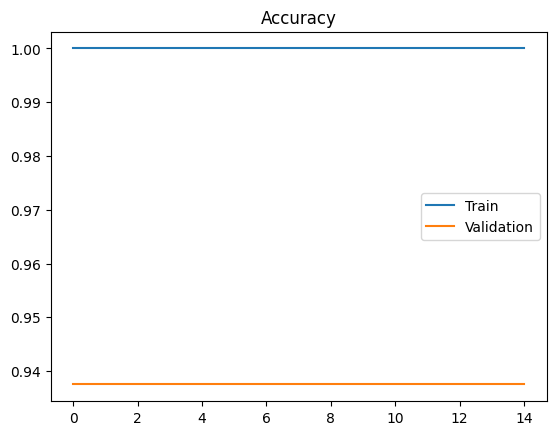

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

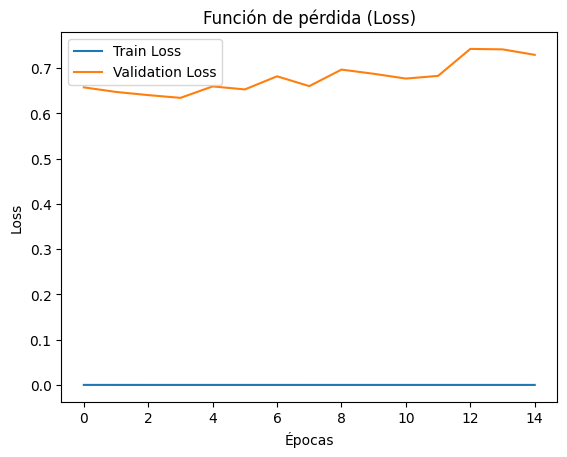

In [ ]:
import matplotlib.pyplot as plt

# Pérdida en entrenamiento y validación
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Función de pérdida (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

In [ ]:
model.save('/content/drive/MyDrive/modelo_pneumonia.h5')